# Métricas do sistemas
---

### Bibliotecas

---

Caso não consiga instalar execute `pip install -r requirements.txt` no terminal

In [72]:
!uv pip install -r ../requirements.txt

Using Python 3.14.3 environment at: /home/victorhugo/obi-benchmarking/.venv
Checked 10 packages in 5ms


In [73]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
import re
from IPython.display import display

In [74]:
path_database = Path("../database")
questions_path = []
        
for folder in list(path_database.iterdir()):
    print(folder)
    if folder.is_dir():
        questions_path.append(folder)
        
problems = []
for question_path in questions_path:
    problems.append(json.loads(Path(question_path / "problem.json").read_text(encoding="utf-8")))

../database/Gomoku
../database/Jogo da Vida
../database/Muro
../database/Lâmpadas do hotel
../database/Chinelos
../database/Hotel
../database/Jogo dos copos
../database/Carnaval
../database/Tiro ao Alvo
../database/Transportes
../database/Álbum da copa
../database/Jogo de Dominós
../database/Arco e flecha
../database/Quadrado Mágico
../database/Quase primo
../database/Lâmpadas
../database/Caça ao Tesouro_2002
../database/Rodovia_2013
../database/Coleção de Upas
../database/Cinema
../database/Fila
../database/Montanha
../database/Chuva
../database/Festa olímpica
../database/Pô, que mão
../database/Relógio
../database/Torre
../database/Mesa redonda
../database/Sorvete
../database/Expressões
../database/Mancha
../database/Direção
../database/Nova avenida
../database/Telescópio
../database/Game Show
../database/Manchas de pele
../database/Temperatura Lunar
../database/Castelos da Nlogônia
../database/Matriz Escada
../database/Pedágio_2002
../database/Fusões
../database/Capitais
../database

In [75]:
for problem in problems:
    print(problem["title"])

Gomoku
Jogo da Vida
Muro
Lâmpadas do hotel
Chinelos
Hotel
Jogo dos copos
Carnaval
Tiro ao Alvo
Transportes
Álbum da copa
Jogo de Dominós
Arco e flecha
Quadrado Mágico
Quase primo
Lâmpadas
Caça ao Tesouro
Rodovia
Coleção de Upas
Cinema
Fila
Montanha
Chuva
Festa olímpica
Pô, que mão
Relógio
Torre
Mesa redonda
Sorvete
Expressões
Mancha
Direção
Nova avenida
Telescópio
Game Show
Manchas de pele
Temperatura Lunar
Castelos da Nlogônia
Matriz Escada
Pedágio
Fusões
Capitais
Falta uma
Sanduíche
Blefe
Tabela do campeonato
Clube dos Cinco
Piso da escola
Caravana
Ônibus
Chocolate
Chocolate em barra
Altas Aventuras
Jogo dos Pinos
Fechadura
Sr. Toupeira
Sr. Sapo
Fita Colorida
Ponto do meio
Ogro
Pirâmide
Game-10
Restaurante de pizza
Zip
Consecutivos
Dança de Formatura
Estrada
Duplas de tênis
Show
Loteria
Cubo Preto
Robô
Etiquetas
Campeonato
Dominó
Reduzindo detalhes em um mapa
Caminho das Pontes
Botas Trocadas
VAR
Dona Lesma
Frequencia na aula
Salada de Frutas
Ciclovias
Pulo do Gato
Semente
Vice-campe

In [76]:
df_problems = pd.DataFrame(problems)
counts_difficulty = {}

for d in df_problems["difficulty"].unique():
    cases = df_problems[df_problems["difficulty"] == d]
    counts_difficulty[d] = len(cases)
    
print(counts_difficulty)

{'Médio': 118, 'Fácil': 126, 'Difícil': 61}


[126, 118, 61]
['Fácil', 'Médio', 'Difícil']


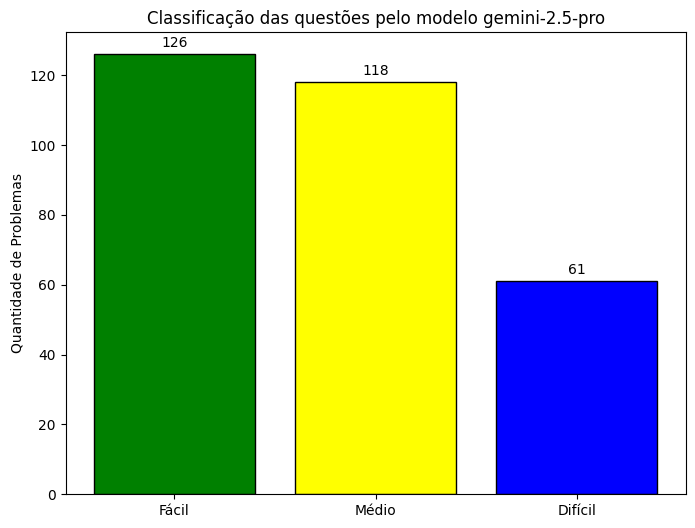

In [77]:
X = ["Fácil", "Médio", "Difícil"]
y = [counts_difficulty[x] for x in X]

print(y)
print(X)
plt.figure(figsize=(8, 6))

bar_plot = plt.bar(X, y, color=['green', 'yellow', 'blue'], edgecolor='black')

plt.bar_label(bar_plot, padding=3)

plt.title("Classificação das questões pelo modelo gemini-2.5-pro")
plt.ylabel('Quantidade de Problemas')
plt.show()

In [78]:
questions_by_years = {}

i = 0
for year in df_problems["year"]:
    if questions_by_years.get(year) is None:
        questions_by_years[year] = []
    
    questions_by_years[year].append(i)
    i += 1
        
for key, count in questions_by_years.items():
    print(f"{key}: {len(count)} quantidades")

names_2015 = []

for index in questions_by_years["2015"]:
    names_2015.append(df_problems.iloc[index]["title"])

print(names_2015)

2017: 24 quantidades
2023: 28 quantidades
2018: 28 quantidades
2016: 23 quantidades
2022: 24 quantidades
2019: 25 quantidades
2012: 17 quantidades
2013: 9 quantidades
2002: 5 quantidades
2014: 23 quantidades
2021: 23 quantidades
2015: 15 quantidades
2001: 5 quantidades
2011: 9 quantidades
2010: 5 quantidades
2024: 25 quantidades
2020: 15 quantidades
2009: 2 quantidades
['Torre', 'Capitais', 'Chocolate em barra', 'Fita Colorida', 'Fila', 'Quebra-cabeça', 'Prêmio do Milhão', 'Móbile', 'Família real', 'Mina', 'Cálculo', 'Cobra coral', 'Letras', 'Arquivos', 'Código']


### ZERO-SHOT vs FEW-SHOT
---

In [79]:
files_path = Path("../output/results/")
dataset = {}
configs = ['_python_few', '_python_zero', '_cpp_few', '_cpp_zero']

for config in configs:
    for path in files_path.rglob('*'):
        if not path.is_file():
            continue

        parts = str(path).split("results_")
        if len(parts) < 2:
            continue

        model = parts[1]
        #print(model)
        data = pd.read_csv(path)

        df_name_2015 = pd.DataFrame()

        for i, name in enumerate(data["question_name"]):
            if name.split("_2015")[0] in names_2015:
                df_name_2015 = pd.concat([df_name_2015, data.iloc[[i]]])

        if not df_name_2015.empty:
            dataset[model] = df_name_2015

count = 0
for data in dataset["gpt_5_4_2026_03_05_python_few.csv"]["total_test_cases"]:
    count += data

print(f"Total de casos de teste: {count}")

Total de casos de teste: 511


In [80]:
rows = []
for model, data in dataset.items():
    rows.append({
        "Modelo": model,
        "AC":  data["AC"].sum()  / count,
        "WA":  data["WA"].sum()  / count,
        "RE":  data["RE"].sum()  / count,
        "TLE": data["TLE"].sum() / count,
        "CE":  data["CE"].sum()  / count,
    })

df_results = pd.DataFrame(rows)

display(
    df_results.style
    .format({
        "AC":  "{:.2%}",
        "WA":  "{:.2%}",
        "RE":  "{:.2%}",
        "TLE": "{:.2%}",
        "CE":  "{:.2%}",
    })
)

,Modelo,AC,WA,RE,TLE,CE
0,stepfun_step_3_5_flash_free_cpp_few.csv,84.93%,0.00%,0.00%,0.00%,0.00%
1,gpt_5_4_2026_03_05_python_few.csv,77.89%,17.42%,0.00%,4.70%,0.00%
2,deepseek_deepseek_v3_2_cpp_few.csv,71.62%,14.68%,2.35%,2.74%,0.00%
3,deepseek_deepseek_v3_2_cpp_zero.csv,69.86%,15.66%,0.00%,5.87%,0.00%
4,anthropic_claude_sonnet_4_6_python_few.csv,74.36%,19.77%,5.87%,0.00%,0.00%
5,x_ai_grok_code_fast_1_python_zero.csv,83.37%,4.70%,0.00%,3.33%,0.00%
6,z_ai_glm_5_python_few.csv,95.30%,2.15%,0.00%,2.54%,0.00%
7,z_ai_glm_5_python_zero.csv,80.63%,2.15%,3.91%,4.70%,0.00%
8,stepfun_step_3_5_flash_free_cpp_zero.csv,91.19%,0.00%,0.00%,0.20%,0.00%
9,deepseek_deepseek_v3_2_python_few.csv,80.82%,12.72%,0.78%,5.68%,0.00%


In [81]:
def parse_model_name(filename):
    name = filename.replace(".csv", "")
    
    lang = "C++" if "_cpp_" in name else "Python"
    shot = "Few-Shot" if "_few" in name else "Zero-Shot"
    
    # Remove sufixos de config
    model = re.sub(r"_(python|cpp)_(few|zero)$", "", name)
    
    return model, lang, shot

rows = []
for model_file, data in dataset.items():
    model, lang, shot = parse_model_name(model_file)
    rows.append({
        "Modelo": model.replace("_", " "),
        "Linguagem": lang,
        "Prompt": shot,
        "AC":  data["AC"].sum()  / count,
        "WA":  data["WA"].sum()  / count,
        "RE":  data["RE"].sum()  / count,
        "TLE": data["TLE"].sum() / count,
        "CE":  data["CE"].sum()  / count,
    })

df_results = pd.DataFrame(rows)

In [82]:
pivot = df_results.pivot_table(
    index="Modelo",
    columns=["Linguagem", "Prompt"],
    values="AC"
).round(4)

display(
    pivot.style
    .format("{:.2%}")
)

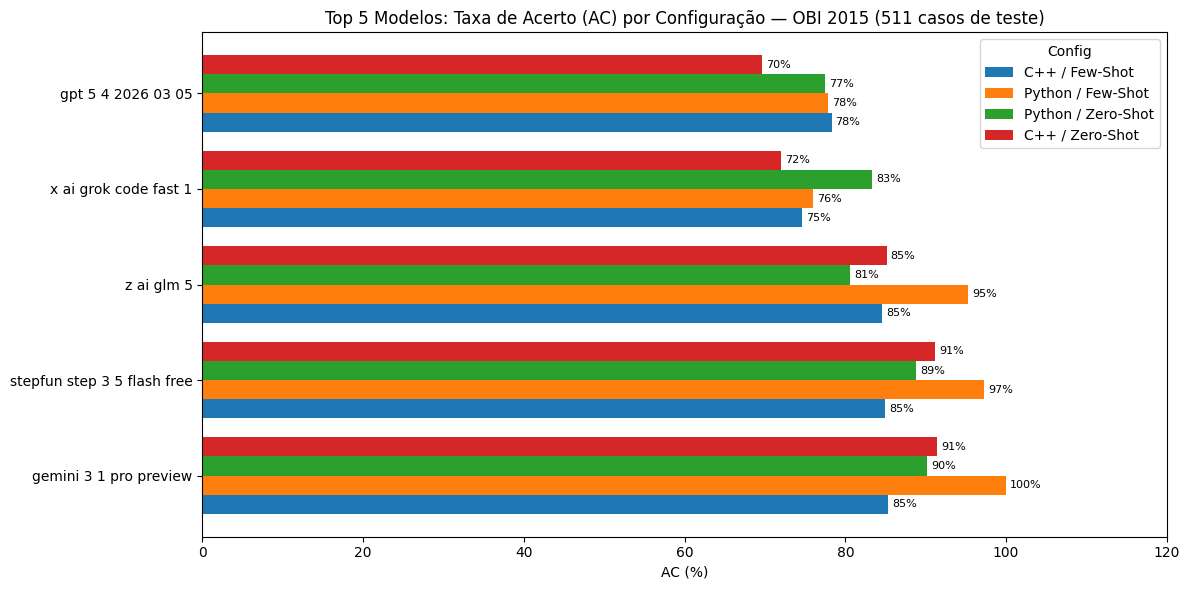

In [83]:
# Top 5 modelos pela média de AC entre todas as configs
top5_models = (
    df_results.groupby("Modelo")["AC"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_top5 = df_results[df_results["Modelo"].isin(top5_models)]

fig, ax = plt.subplots(figsize=(12, 6))  # menor pois são só 5 modelos

configs = df_top5[["Linguagem", "Prompt"]].drop_duplicates()
models = top5_models
y = np.arange(len(models))
height = 0.2

for i, (_, cfg) in enumerate(configs.iterrows()):
    subset = df_top5[
        (df_top5["Linguagem"] == cfg.Linguagem) &
        (df_top5["Prompt"] == cfg.Prompt)
    ].set_index("Modelo")["AC"].reindex(models).fillna(0)

    bars = ax.barh(y + i * height, subset * 100, height, label=f"{cfg.Linguagem} / {cfg.Prompt}")

    for bar, val in zip(bars, subset * 100):
        if val > 0:
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%",
                ha="left", va="center", fontsize=8
            )

ax.set_yticks(y + height * 1.5)
ax.set_yticklabels(models, fontsize=10)
ax.set_xlabel("AC (%)")
ax.set_title("Top 5 Modelos: Taxa de Acerto (AC) por Configuração — OBI 2015 (511 casos de teste)")
ax.legend(title="Config")
ax.set_xlim(0, 120)
ax.grid(False)

plt.tight_layout()
plt.show()

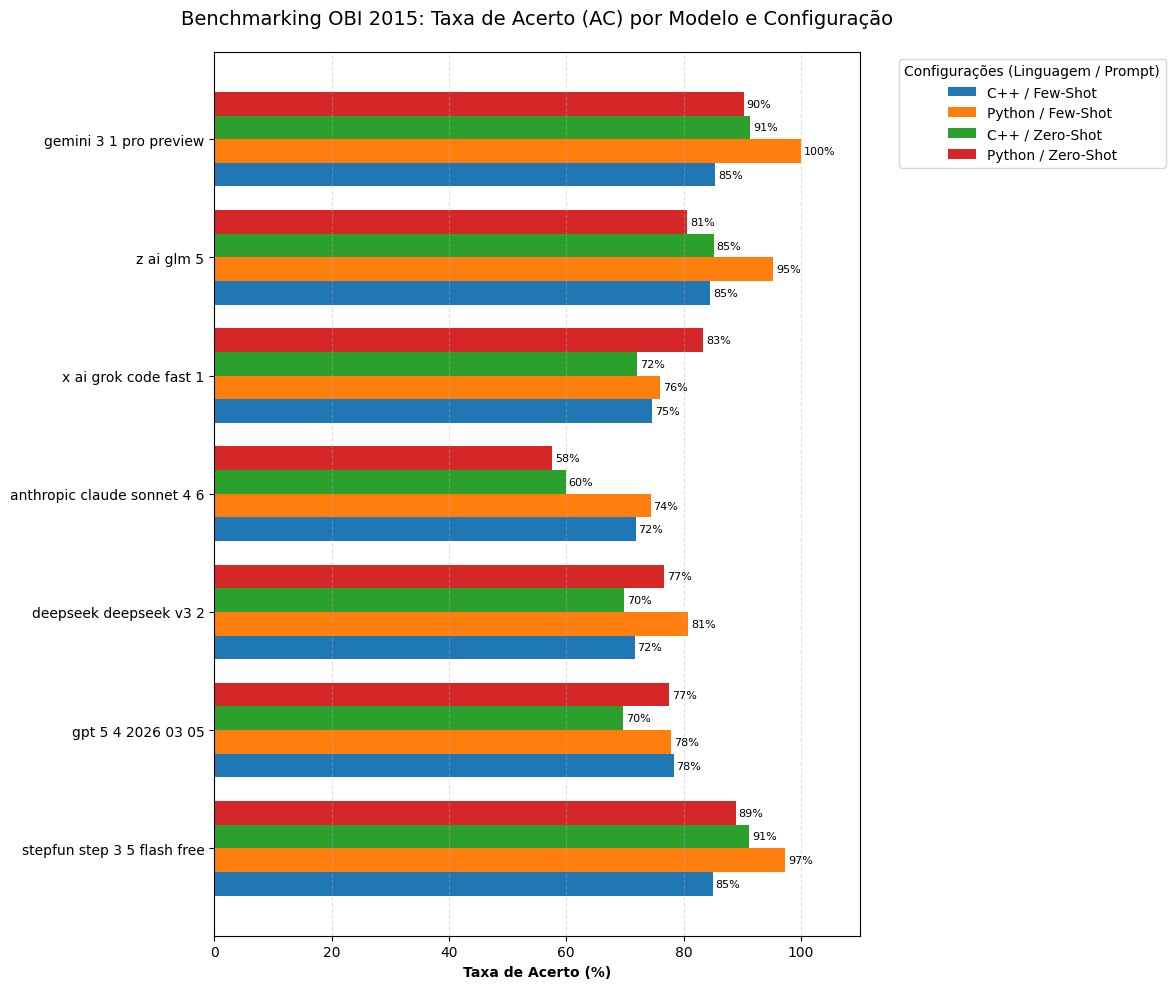

In [84]:
fig, ax = plt.subplots(figsize=(12, 10))

configs = df_results[["Linguagem", "Prompt"]].drop_duplicates()
models = df_results["Modelo"].unique()


y_indices = np.arange(len(models))
bar_height = 0.2
offset = 0 

for i, (_, cfg) in enumerate(configs.iterrows()):
    subset = df_results[
        (df_results["Linguagem"] == cfg.Linguagem) & 
        (df_results["Prompt"] == cfg.Prompt)
    ].set_index("Modelo")["AC"].reindex(models).fillna(0)
    
    current_y = y_indices + (i * bar_height)
    label_text = f"{cfg.Linguagem} / {cfg.Prompt}"
    
    bars = ax.barh(current_y, subset * 100, bar_height, label=label_text)
    
    for bar in bars:
        width = bar.get_width()
        if width > 0:
            ax.text(
                width + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.0f}%", 
                ha="left", 
                va="center", 
                fontsize=8
            )

ax.set_yticks(y_indices + (len(configs) * bar_height) / 2 - (bar_height / 2))
ax.set_yticklabels(models, fontsize=10)
ax.set_xlabel("Taxa de Acerto (%)", fontweight='bold')
ax.set_title("Benchmarking OBI 2015: Taxa de Acerto (AC) por Modelo e Configuração", fontsize=14, pad=20)
ax.set_xlim(0, 110)
ax.legend(title="Configurações (Linguagem / Prompt)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Estatísticas do Judge

---

In [85]:
def average(data):
    n = len(data)
    count = 0
    
    for value in data:
        count += value
        
    return float(count/n)

In [86]:
def per_ac_questions(data):
    n = len(data)
    count = 0
    for value in data["judge_predict"]:
        if value == "AC":
            count += 1
            
    return float(count/n)

In [87]:
files_path = Path("../output/results/")

dataset = {}

for path in list(files_path.rglob('*')):        
    model = str(path).split("results_")[1]
    if not "_python_few" in model:
        continue
    
    model = model.split("_python_few")[0]
    
    dataset[model] = pd.read_csv(path)

In [96]:
metrics = {}

for key, data in dataset.items():
    
    row = {}
    
    hard_questions = data[data["difficulty"] == "Difícil"]
    row['hard_ac'] = per_ac_questions(hard_questions)
    
    medium_questions = data[data["difficulty"] == "Médio"]
    row['medium_ac'] = per_ac_questions(medium_questions)
    
    easy_questions = data[data["difficulty"] == "Fácil"]
    row['easy_ac'] = per_ac_questions(easy_questions)
    
    row['avg_tokens'] = average(data["total_tokens"])
    row['avg_cost'] = average(data["cost_prompt"])
    row['avg_create_code'] = average(data["llm_code_creation_time"])
    
    metrics[key] = row

In [102]:
rows = []
names_model = {
    "anthropic_claude_sonnet_4_6": "Sonnet 4.6",
    "gpt_5_4_2026_03_05": "GPT 5.4",
    "z_ai_glm_5": "GLM 5",
    "deepseek_deepseek_v3_2": "DeepSeek V3.2",
    "x_ai_grok_code_fast_1": "Grok Code Fast 1",
    "stepfun_step_3_5_flash_free": "Step 3.5 Flash Free",
    "gemini_3_1_pro_preview": "Gemini 3.1 Pro"
}

for key, data in metrics.items():
    rows.append({
        "Modelo":                          names_model[key],
        "Fácil AC (%)":                    data["easy_ac"] * 100,
        "Médio AC (%)":                    data["medium_ac"] * 100,
        "Difícil AC (%)":                  data["hard_ac"] * 100,
        "Média de Tokens":                 data["avg_tokens"],
        "Custo Médio (U$)":                data["avg_cost"],
        "Tempo Médio de Geração (s)":      data["avg_create_code"],
    })

df = pd.DataFrame(rows)

display(
    df.style
    .format({
        "Fácil AC (%)":                "{:.2f}",
        "Médio AC (%)":                "{:.2f}",
        "Difícil AC (%)":              "{:.2f}",
        "Média de Tokens":             "{:.0f}",
        "Custo Médio (U$)":            "{:.4f}",
        "Tempo Médio de Geração (s)":  "{:.0f}",
    })
)

,Modelo,Fácil AC (%),Médio AC (%),Difícil AC (%),Média de Tokens,Custo Médio (U$),Tempo Médio de Geração (s)
0,GPT 5.4,89.68,68.64,40.98,1499,0.0065,3
1,Sonnet 4.6,88.89,83.05,45.90,2877,0.0237,18
2,GLM 5,95.24,88.98,65.57,7830,0.0220,115
3,DeepSeek V3.2,85.71,62.71,26.23,1785,0.0007,18
4,Grok Code Fast 1,90.62,67.27,40.74,8181,0.0104,27
5,Step 3.5 Flash Free,100.00,89.66,70.00,12516,0.0000,105
6,Gemini 3.1 Pro,97.62,94.92,93.44,1707,0.0061,54


In [90]:
for key, data in dataset.items():
    total_tokens_cases = 0

    for count_test in data["total_tokens"]:
        total_tokens_cases += count_test
        
    print(f"Total de tokens [{key}]: {total_tokens_cases}")

Total de tokens [gpt_5_4_2026_03_05]: 457127
Total de tokens [anthropic_claude_sonnet_4_6]: 877409
Total de tokens [z_ai_glm_5]: 2388250
Total de tokens [deepseek_deepseek_v3_2]: 544573
Total de tokens [x_ai_grok_code_fast_1]: 1194384
Total de tokens [stepfun_step_3_5_flash_free]: 801056
Total de tokens [gemini_3_1_pro_preview]: 520516


In [91]:
for key, data in dataset.items():
    total_time = 0

    for time in data["llm_code_creation_time"]:
        total_time += time
        
    total_time = int(total_time)
    seg = total_time % 60
    total_time = total_time - seg
    total_time = total_time / 60 # total_time em minutos
    
    h = total_time / 60
    min = total_time % 60
    
    print(f"Tem de resolução das questões pelo modelo {key}: {int(h)}h {int(min)} min {seg}s")

Tem de resolução das questões pelo modelo gpt_5_4_2026_03_05: 0h 16 min 5s
Tem de resolução das questões pelo modelo anthropic_claude_sonnet_4_6: 1h 33 min 42s
Tem de resolução das questões pelo modelo z_ai_glm_5: 9h 42 min 31s
Tem de resolução das questões pelo modelo deepseek_deepseek_v3_2: 1h 32 min 26s
Tem de resolução das questões pelo modelo x_ai_grok_code_fast_1: 1h 5 min 23s
Tem de resolução das questões pelo modelo stepfun_step_3_5_flash_free: 1h 51 min 43s
Tem de resolução das questões pelo modelo gemini_3_1_pro_preview: 4h 35 min 28s


In [92]:
total = 0

for key, data in dataset.items():
    total_cost = 0

    for count_test in data["cost_prompt"]:
        total_cost += count_test
    
    total += total_cost
    
    print(f"Total de tokens [{key}]: U$ {total_cost:.2f}")
    
print(f"Valor gasto atualmente: U$ {total:.2f}")

Total de tokens [gpt_5_4_2026_03_05]: U$ 1.98
Total de tokens [anthropic_claude_sonnet_4_6]: U$ 7.22
Total de tokens [z_ai_glm_5]: U$ 6.72
Total de tokens [deepseek_deepseek_v3_2]: U$ 0.21
Total de tokens [x_ai_grok_code_fast_1]: U$ 1.51
Total de tokens [stepfun_step_3_5_flash_free]: U$ 0.00
Total de tokens [gemini_3_1_pro_preview]: U$ 1.86
Valor gasto atualmente: U$ 19.51
